In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

In [2]:
df=pd.read_csv("housing.csv")

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [5]:
X=df
X=X.drop(columns=['median_house_value'])
Y=df['median_house_value']

<h3>Train Test Splitting</h3>

In [6]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2)

<h3>Handling Outliers</h3>

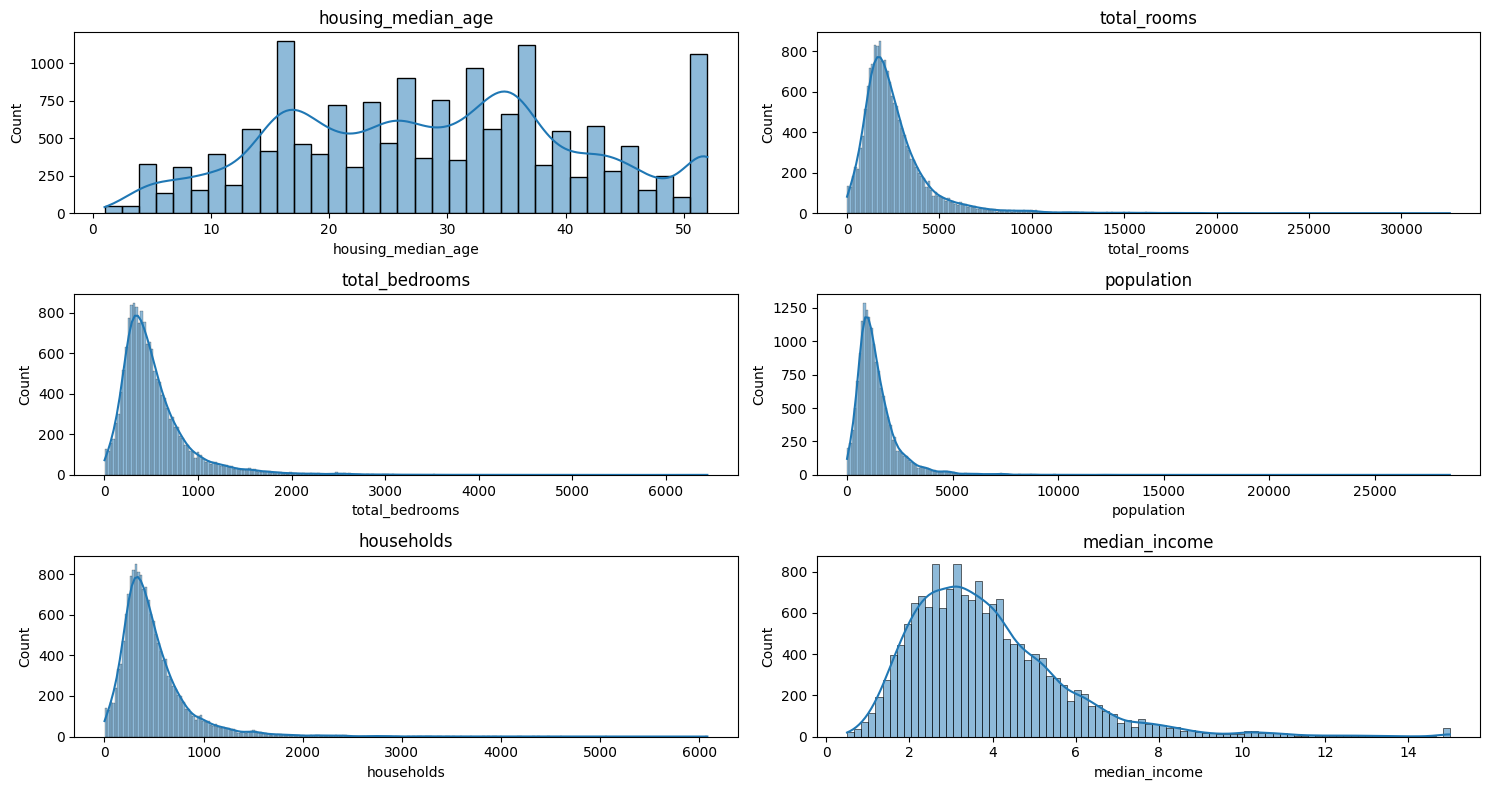

In [7]:
fig , axes = plt.subplots(nrows=3,ncols=2,figsize=(15,8))
axes=axes.flatten()

sns.histplot(x_train['housing_median_age'],kde=True,ax=axes[0])
axes[0].set_title("housing_median_age")

sns.histplot(x_train['total_rooms'],kde=True,ax=axes[1])
axes[1].set_title("total_rooms")

sns.histplot(x_train['total_bedrooms'],kde=True,ax=axes[2])
axes[2].set_title("total_bedrooms")

sns.histplot(x_train['population'],kde=True,ax=axes[3])
axes[3].set_title("population")

sns.histplot(x_train['households'],kde=True,ax=axes[4])
axes[4].set_title("households")

sns.histplot(x_train['median_income'],kde=True,ax=axes[5])
axes[5].set_title("median_income")

plt.tight_layout()
plt.show()

In [8]:
# housing_median_age distribution is kind of normal
lower=np.mean(x_train['housing_median_age']) - 3*np.std(x_train['housing_median_age'])
upper=np.mean(x_train['housing_median_age']) + 3*np.std(x_train['housing_median_age'])
total_outliers=x_train['housing_median_age'][(x_train['housing_median_age']<lower) & (x_train['housing_median_age']>upper)].count()
print(total_outliers)

0


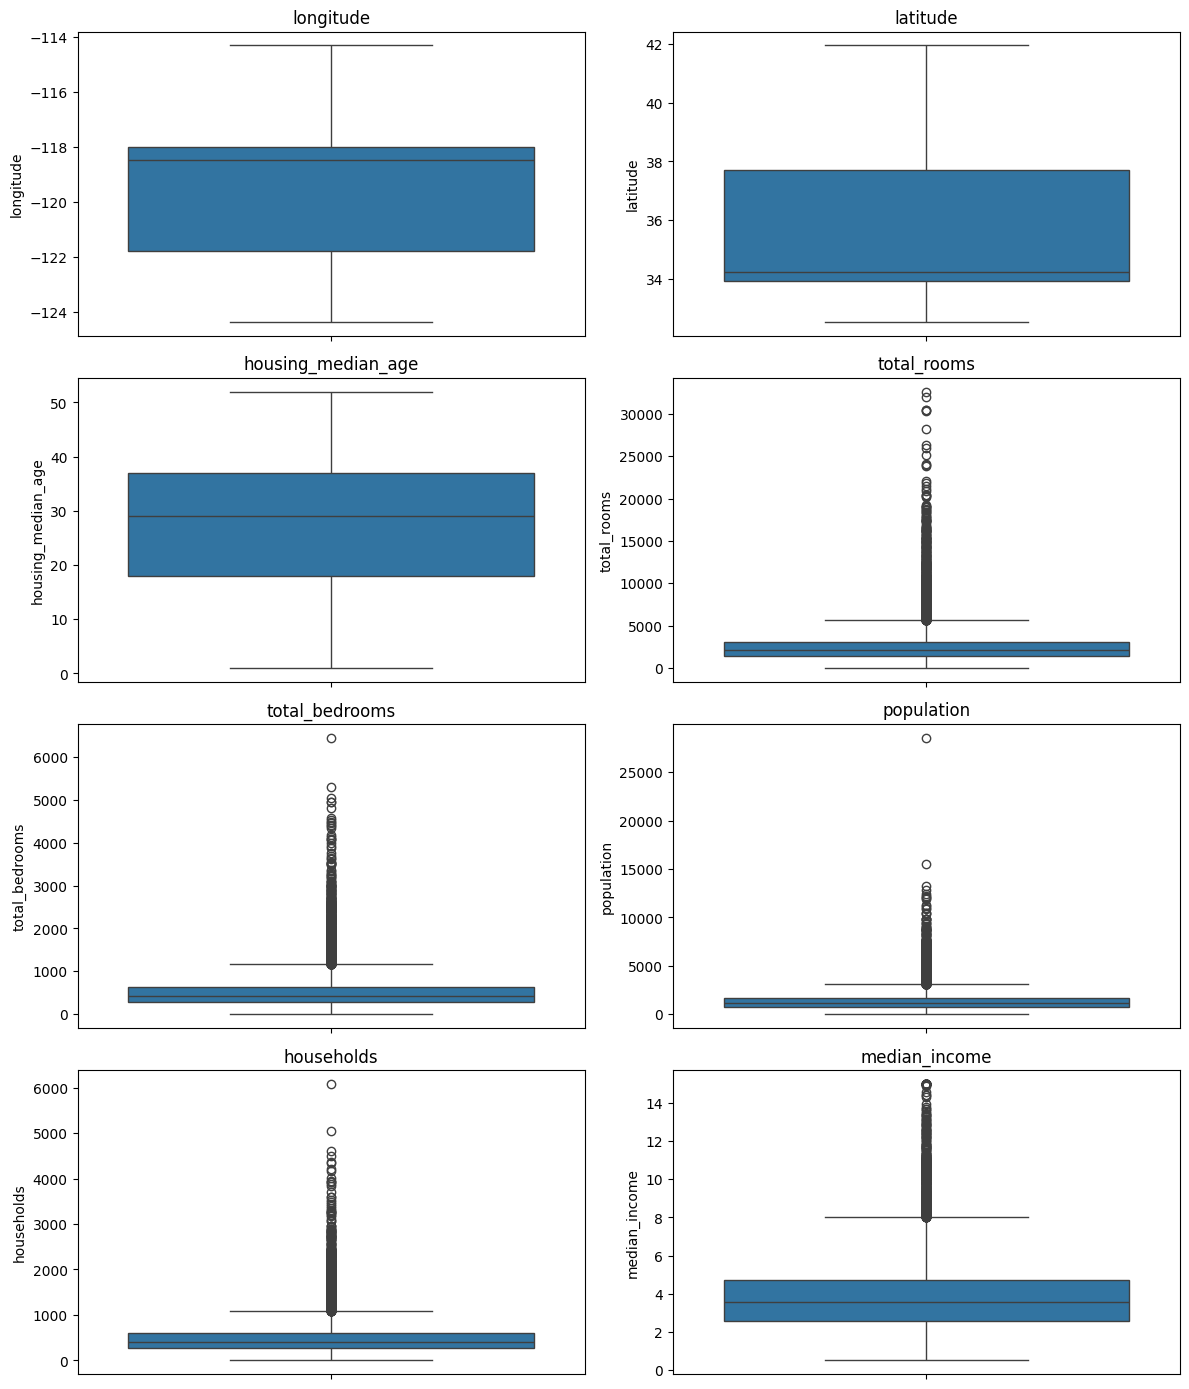

In [9]:
fig , axes = plt.subplots(nrows=4,ncols=2,figsize=(12,14))
axes=axes.flatten()

columns=x_train.columns
for a,col in enumerate(columns,start=0):
    if (x_train[col].dtype != 'str'):
        if a<len(axes):
            sns.boxplot(x_train[col],ax=axes[a])
            axes[a].set_title(col)
        else:
            break
plt.tight_layout()
plt.show()

In [10]:
columns=x_train.columns
outlier_cols=[]
is_first_run=True
def countOutliers(columns):
    for col in columns:
        if (col !='housing_median_age') & (x_train[col].dtype != 'str'):
            Q1=x_train[col].quantile(0.25)
            Q3=x_train[col].quantile(0.75)
            iqr=Q3-Q1

            lower=Q1 - (1.5 * iqr)
            upper=Q3 + (1.5 * iqr)

            total_outliers=x_train[col][(x_train[col]>upper) | (x_train[col]<lower)].count()
            prcent= (total_outliers / x_train[col].shape[0])
            if (is_first_run) & (prcent*100 > 0):
                outlier_cols.append(col)
            print(f"{col} ::: Total Outliers : {total_outliers} ({prcent:.2%}) ")

outliers_filled=False
countOutliers(columns)

longitude ::: Total Outliers : 0 (0.00%) 
latitude ::: Total Outliers : 0 (0.00%) 
total_rooms ::: Total Outliers : 1037 (6.28%) 
total_bedrooms ::: Total Outliers : 1034 (6.26%) 
population ::: Total Outliers : 956 (5.79%) 
households ::: Total Outliers : 983 (5.95%) 
median_income ::: Total Outliers : 555 (3.36%) 


In [11]:
for col in outlier_cols:
    Q1=x_train[col].quantile(0.25)
    Q3=x_train[col].quantile(0.75)
    iqr=Q3-Q1
    lower=Q1 - (1.5 * iqr)
    upper=Q3 + (1.5 * iqr)

    x_train[col]=x_train[col].clip(lower=lower,upper=upper)
    print(f"clipped column : {col}")

clipped column : total_rooms
clipped column : total_bedrooms
clipped column : population
clipped column : households
clipped column : median_income


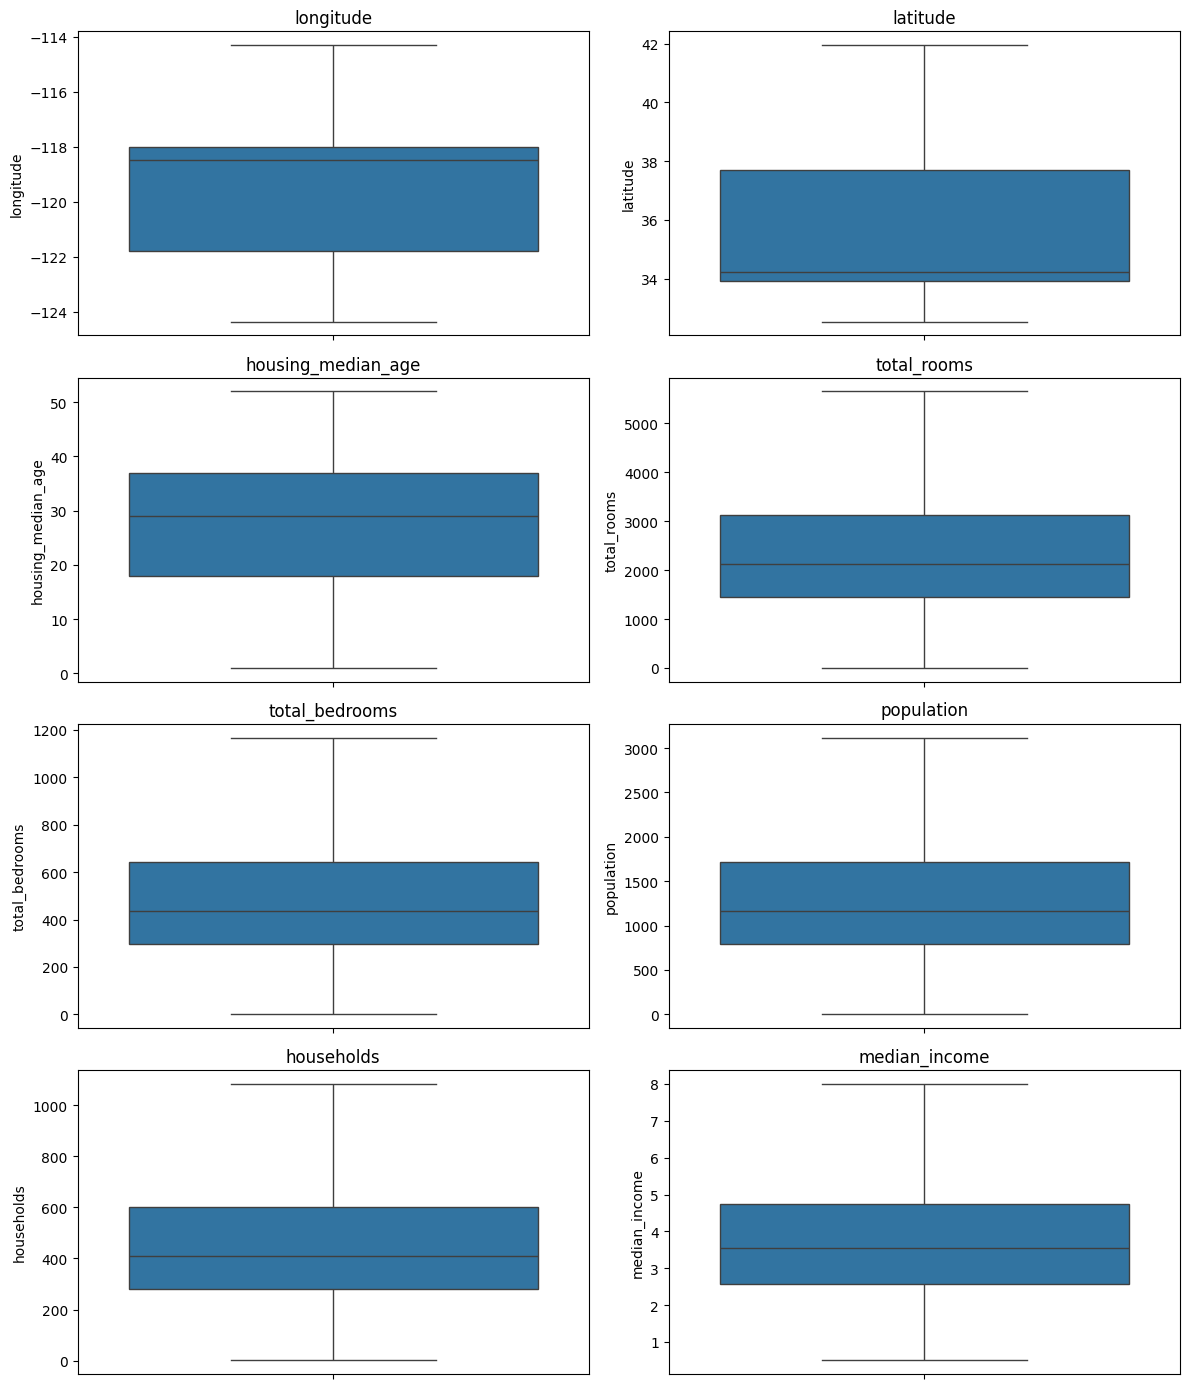

In [12]:
# after outliers handling
fig , axes = plt.subplots(nrows=4,ncols=2,figsize=(12,14))
axes=axes.flatten()

columns=x_train.columns
for a,col in enumerate(columns,start=0):
    if (x_train[col].dtype != 'str'):
        if a<len(axes):
            sns.boxplot(x_train[col],ax=axes[a])
            axes[a].set_title(col)
        else:
            break
plt.tight_layout()
plt.show()

In [13]:
cols=[col for col in x_train.columns if x_train[col].dtype != 'str']
countOutliers(cols)

longitude ::: Total Outliers : 0 (0.00%) 
latitude ::: Total Outliers : 0 (0.00%) 
total_rooms ::: Total Outliers : 0 (0.00%) 
total_bedrooms ::: Total Outliers : 0 (0.00%) 
population ::: Total Outliers : 0 (0.00%) 
households ::: Total Outliers : 0 (0.00%) 
median_income ::: Total Outliers : 0 (0.00%) 


<h3>Handling Missing Values</h3>

In [14]:
x_train.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        167
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

In [15]:
x_train['is_missing']=x_train['total_bedrooms'].isnull().astype(int)
print(x_train.groupby('is_missing')['median_income'].mean())

is_missing
0    3.794394
1    3.831635
Name: median_income, dtype: float64


In [16]:
# as the mediam income for both types of houses (with and without bedrooms) is almost identical so we can tell that the data is Missing Completely at Random

In [17]:
x_train['total_bedrooms'].isnull().mean()*100

np.float64(1.0113856589147288)

In [18]:
x_train.drop(columns=['is_missing'],inplace=True)

In [19]:
imputer=SimpleImputer(strategy='median')
bedrooms_imputer=imputer.fit_transform(x_train[['total_bedrooms']])
bedrooms_imputer_test=imputer.transform(x_test[['total_bedrooms']])

x_train.loc[:,'total_bedrooms']=bedrooms_imputer
x_test.loc[:,'total_bedrooms']=bedrooms_imputer_test

In [20]:
x_train.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

<h3>Handling Categorical Columns</h3>

In [21]:
ohe=OneHotEncoder(drop='first',sparse_output=False)
ocean_train=ohe.fit_transform(x_train[['ocean_proximity']])
ocean_test=ohe.transform(x_test[['ocean_proximity']])
names=ohe.get_feature_names_out()

ocean_train_df=pd.DataFrame(ocean_train,columns=names,index=x_train.index)
ocean_test_df=pd.DataFrame(ocean_test,columns=names,index=x_test.index)

x_train=pd.concat([x_train.drop(columns=['ocean_proximity']),ocean_train_df],axis=1)
x_test=pd.concat([x_test.drop(columns=['ocean_proximity']),ocean_test_df],axis=1)

In [22]:
x_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
9470,-123.79,39.44,16.0,2017.0,423.0,1177.0,414.0,3.2171,0.0,0.0,0.0,0.0
13115,-121.13,38.37,10.0,1034.0,153.0,478.0,155.0,7.0326,1.0,0.0,0.0,0.0
18876,-122.25,38.09,48.0,833.0,188.0,652.0,165.0,2.2417,0.0,0.0,1.0,0.0
4907,-118.27,34.01,42.0,990.0,289.0,1167.0,281.0,1.4524,0.0,0.0,0.0,0.0
18313,-122.13,37.43,32.0,4398.0,878.0,1799.0,792.0,4.7375,0.0,0.0,1.0,0.0


<h3>Feature Transformation</h3>

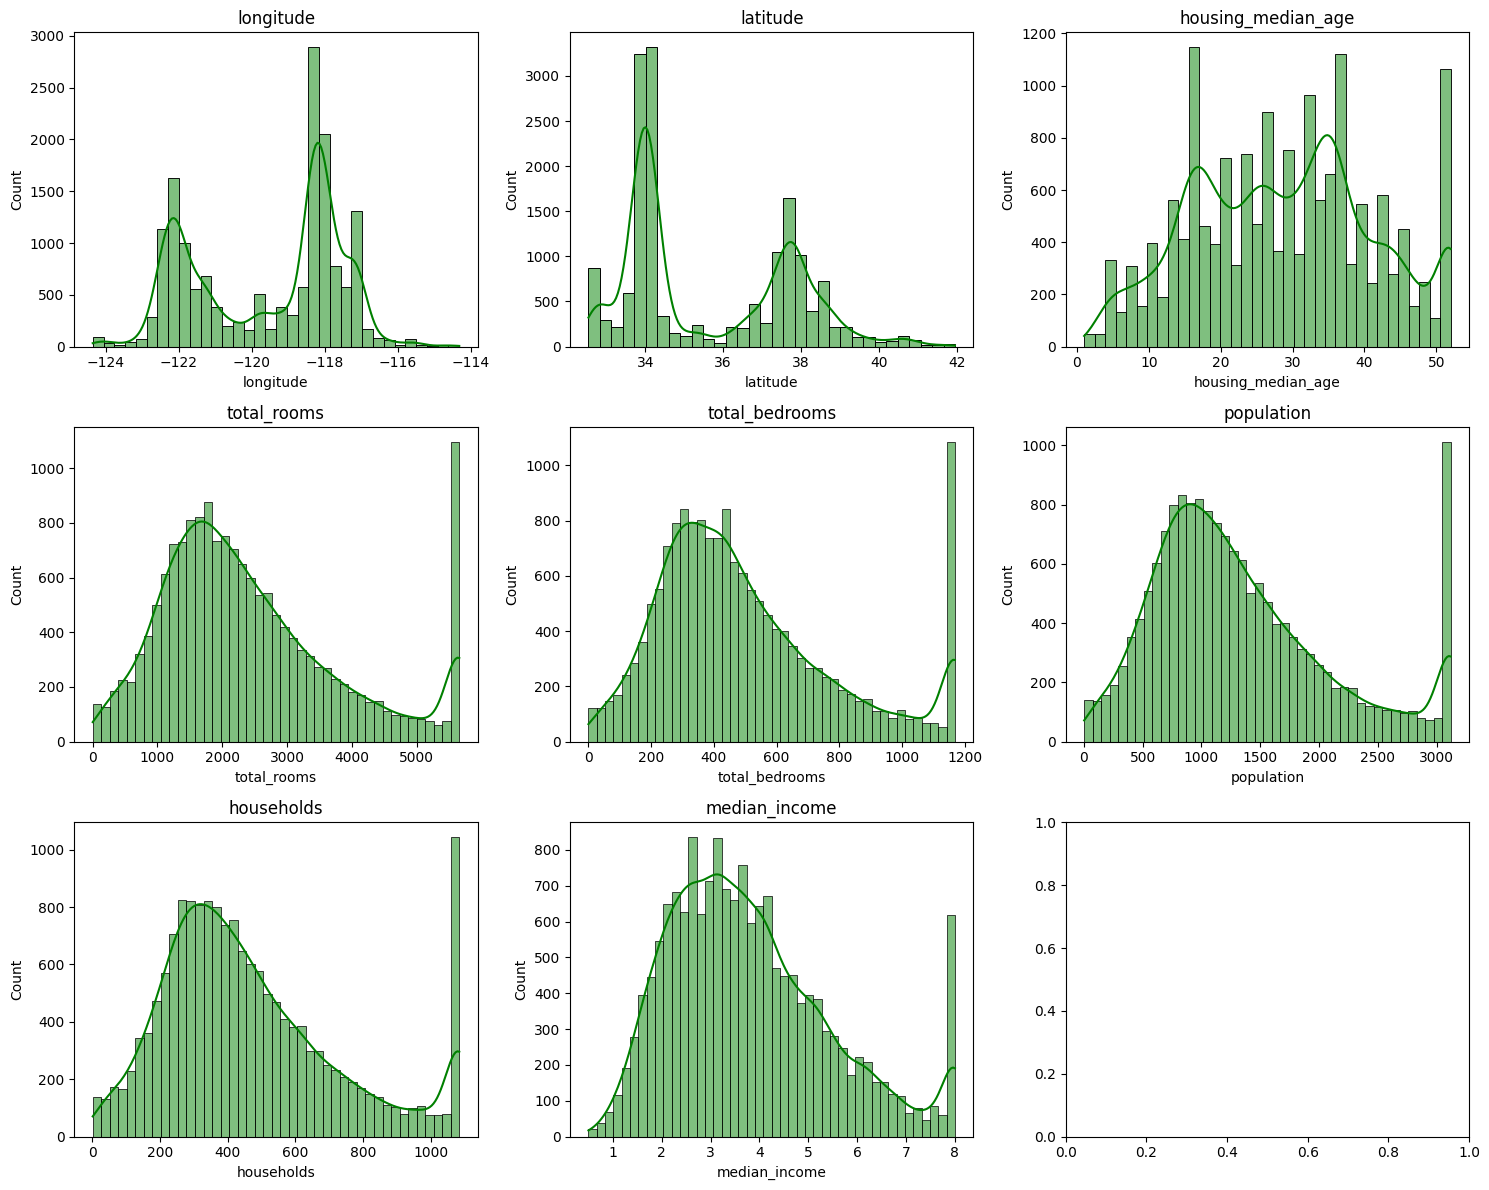

In [23]:
req_cols=[col for col in x_train.columns if col not in ['ocean_proximity_INLAND','ocean_proximity_ISLAND','ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']]

fig , axes = plt.subplots(nrows=3,ncols=3,figsize=(15,12))
axes=axes.ravel()
for a,col in enumerate(req_cols):
    if a<len(axes):
        sns.histplot(x_train[col],ax=axes[a],kde=True,color='green')
        axes[a].set_title(col)
    else:
        break

plt.tight_layout()
plt.show()

In [25]:
pt=PowerTransformer(method='yeo-johnson')
cols_to_transform=['longitude','latitude','housing_median_age','total_rooms','total_bedrooms','population','households','median_income']

x_train[cols_to_transform]=pt.fit_transform(x_train[cols_to_transform])
x_test[cols_to_transform]=pt.transform(x_test[cols_to_transform])

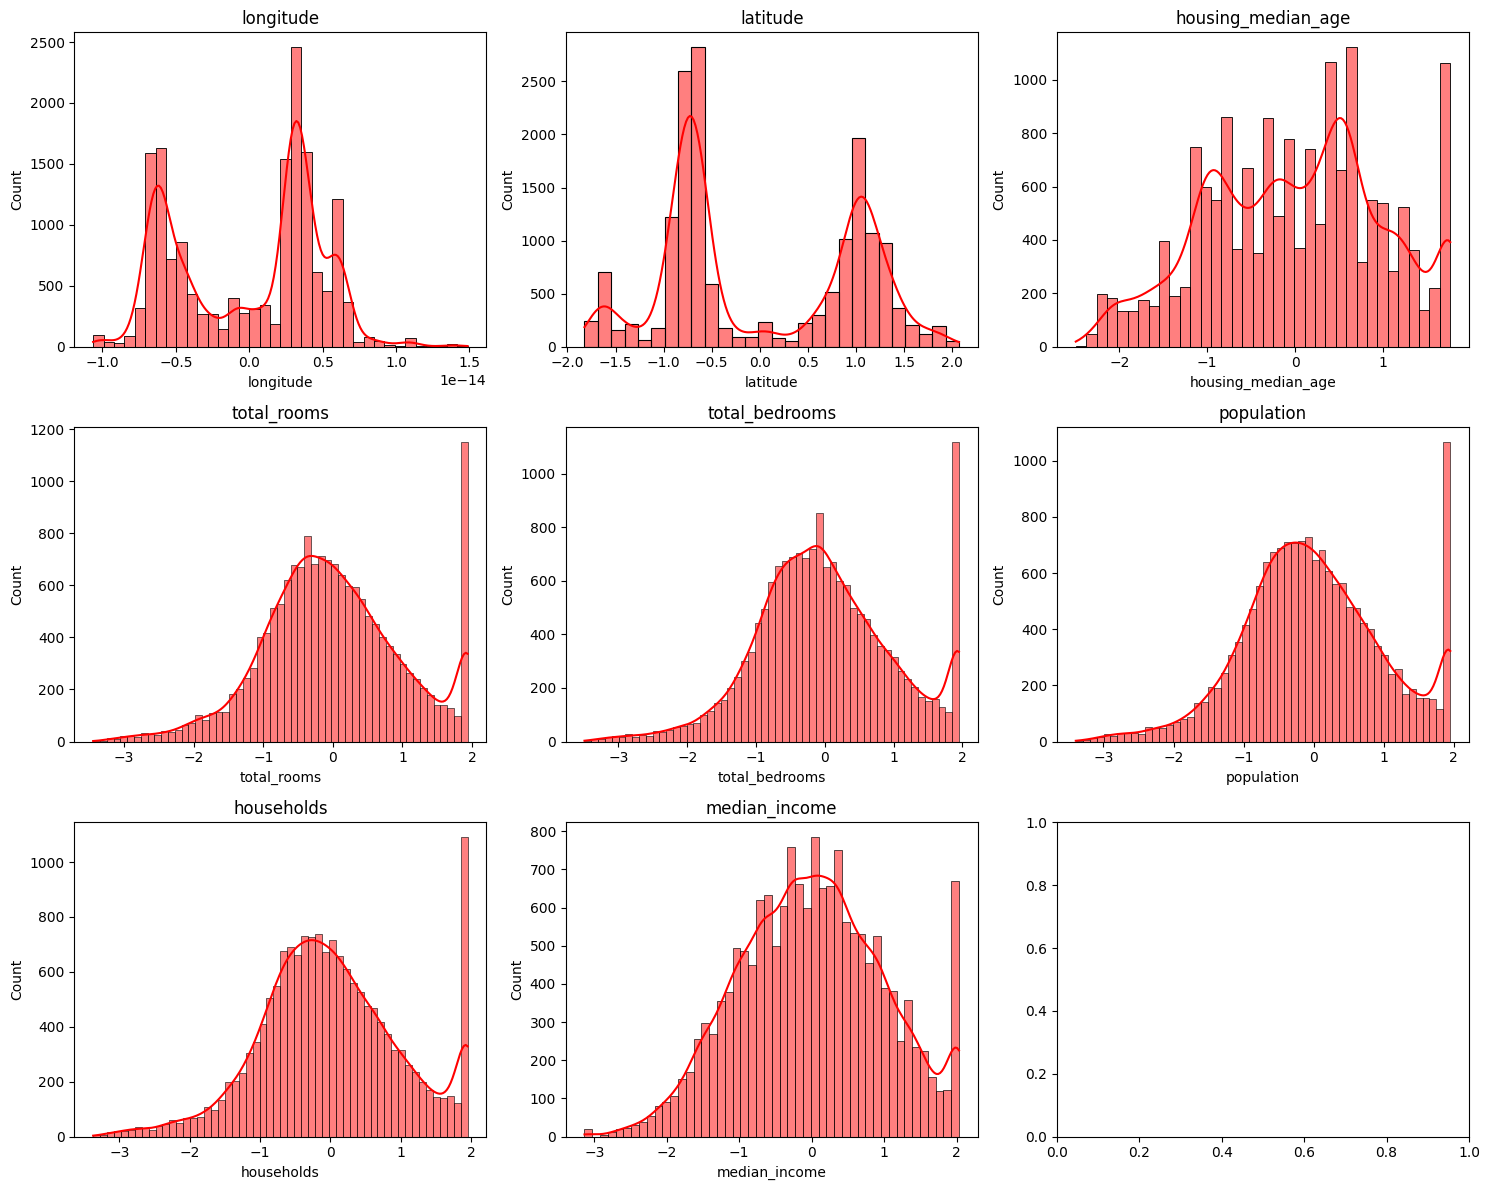

In [26]:
req_cols=[col for col in x_train.columns if col not in ['ocean_proximity_INLAND','ocean_proximity_ISLAND','ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']]

fig , axes = plt.subplots(nrows=3,ncols=3,figsize=(15,12))
axes=axes.ravel()
for a,col in enumerate(req_cols):
    if a<len(axes):
        sns.histplot(x_train[col],ax=axes[a],kde=True,color='red')
        axes[a].set_title(col)
    else:
        break

plt.tight_layout()
plt.show()

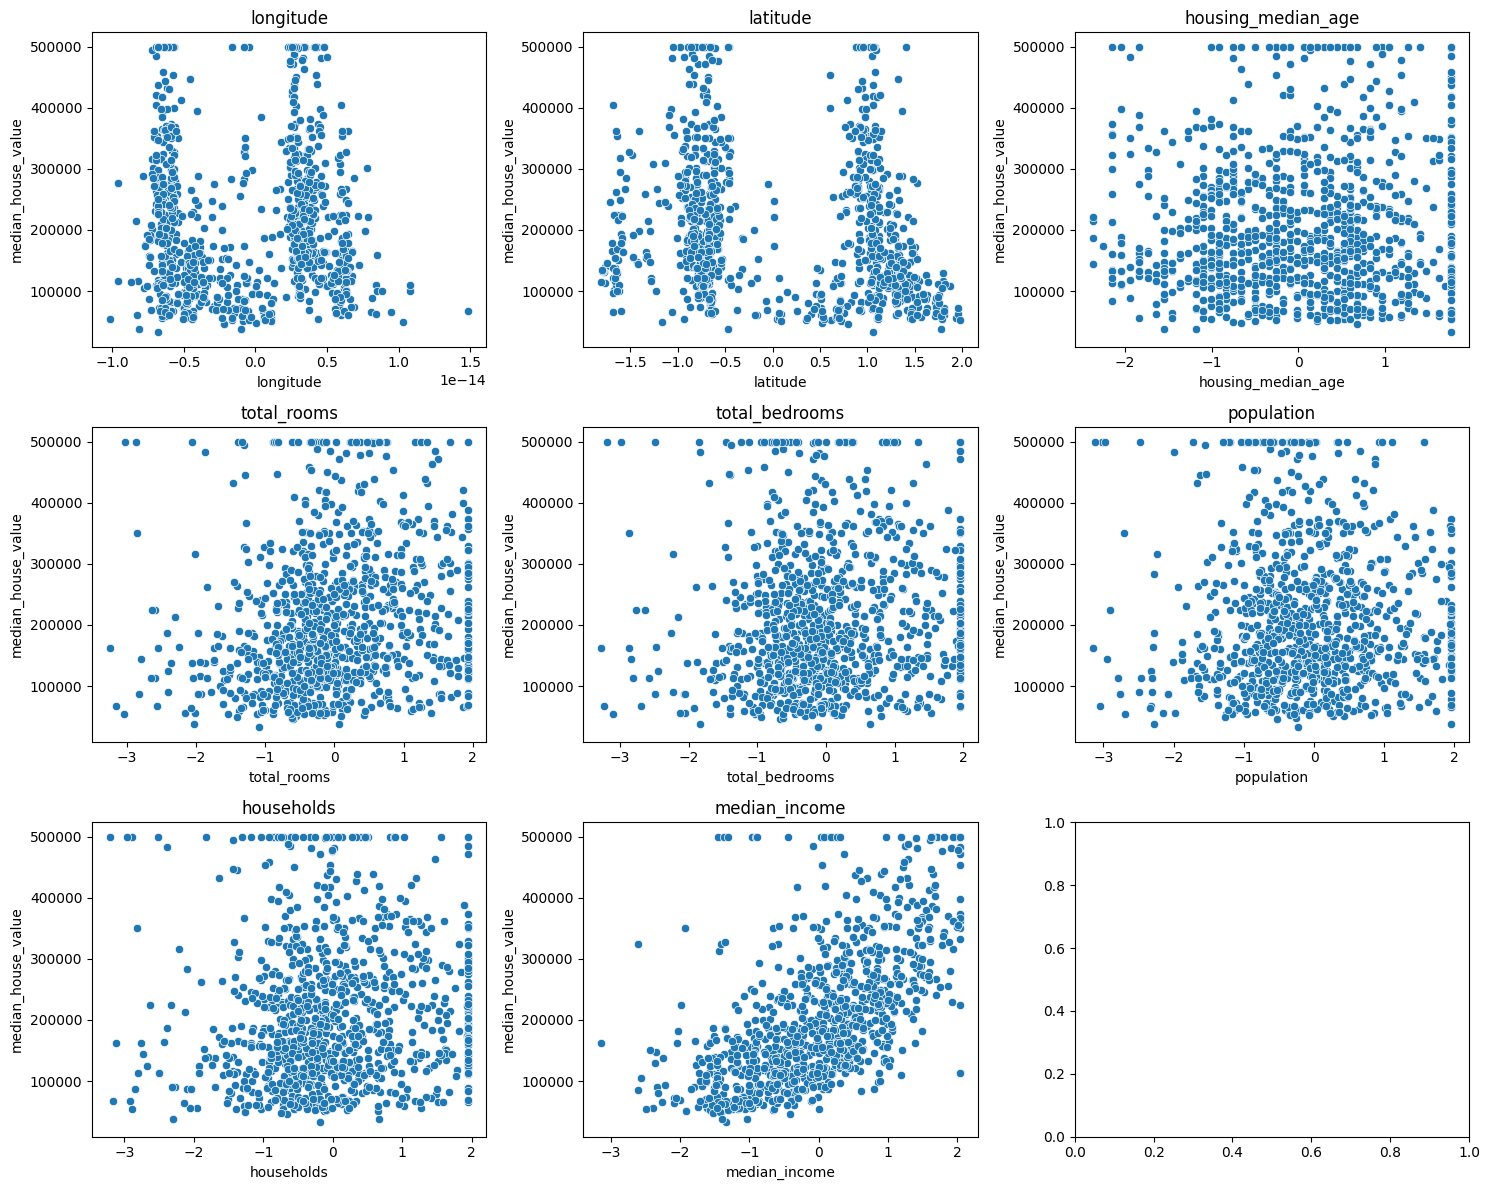

In [27]:
r_cols=[col for col in x_train.columns if col not in ['ocean_proximity_INLAND','ocean_proximity_ISLAND','ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']]
fig , axes = plt.subplots(nrows=3,ncols=3,figsize=(15,12))
axes=axes.ravel()

for a,col in enumerate(r_cols):
    if a<len(axes):
        sns.scatterplot(x=x_train[col][:1000],y=y_train[:1000],ax=axes[a])
        axes[a].set_title(col)
    else:
        break

plt.tight_layout()
plt.show()

<h3>Feature Scaling</h3>

In [28]:
ss=StandardScaler()
ss.set_output(transform='pandas')

x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

<h3>Polynomial Features</h3>

In [29]:
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

<h3>Training Model & Prediction</h3>

In [30]:
rge=Ridge(alpha=1)
rge.fit(x_train_poly,y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [51]:
y_pred2=rge.predict(x_test_poly)
print(r2_score(y_test,y_pred2))

0.613696266297204
